# ハミルトニアンシミュレーションの回路資源比較

Trotter–Suzuki、QSVT、multiproduct formula (MPF) を、同じ Pauli 和と誤差予算の下で比較します。小規模系では実際の statevector、大規模系では密行列を作らないゲート分解モデルを使います。

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd

from hamiltonian_resources import (
    BenchmarkConfig, HamiltonianSpec, MultiproductMethod, QSVTMethod,
    TimeScaling, TrotterMethod, build_simulation_circuit,
    compare_plan_with_exact, estimate_resources, plot_benchmark,
    run_benchmark, transverse_field_ising,
)
pd.set_option("display.max_columns", None)

## ベンチマーク設定（ここを編集）

system-size sweepでは相互作用が鎖全体へ広がる時間を比較するため、既定で $t(n)=n$ とします。`TIME_PER_QUBIT`を変更すると $t(n)=\tau n$、`TimeScaling("fixed", t)`に変えると固定時刻になります。

In [3]:
SYSTEM_SIZES = np.geomspace(3, 200, num=15, dtype=np.int_)
TARGET_ERRORS = np.logspace(-1, -9, 12)
TIME_PER_QUBIT = 1.0

benchmark_config = BenchmarkConfig(
    hamiltonian=HamiltonianSpec(
        model="transverse_field_ising",
        parameters={"coupling": 1.0, "field": 3.0, "periodic": False},
    ),
    system_sizes=SYSTEM_SIZES,
    target_errors=TARGET_ERRORS,
    time=TimeScaling("proportional", TIME_PER_QUBIT),
    fixed_system_size=8,
    fixed_target_error=1e-8,
    methods=[
        *(TrotterMethod(order) for order in (1, 2, 4, 6)),
        *(
            MultiproductMethod(
                terms, error_method="low2019-l1-ideal-rigorous"
            )
            for terms in (3, 5, 7)
        ),
        QSVTMethod(),
    ],
)

## 1. ハミルトニアン入力

例として $H=-J\sum_i Z_iZ_{i+1}-h\sum_iX_i$ を使います。Qiskit の Pauli label は右端が qubit 0 です。任意の Pauli 和は `PauliHamiltonian.from_terms` で渡せます。

In [4]:
H = transverse_field_ising(3, coupling=1.0, field=0.7)
print(H.name, H.terms)
print(f"terms={H.term_count}, alpha=sum|h_j|={H.alpha:.3f}")

TFIM-3 (('IZZ', -1.0), ('ZZI', -1.0), ('IIX', -0.7), ('IXI', -0.7), ('XII', -0.7))
terms=5, alpha=sum|h_j|=4.100


## 2. 単一点resource評価とalgorithm plan

`estimate_resources`はHamiltonian・手法・時刻・目標誤差からparameterを1回だけ選択し、backend非依存のimmutable planと構造化解析resource結果を返します。論理演算数は`report.plan.logical_counts`が正本で、T/CNOT、temporary-AND、backend work qubitは`report.resources`とprovenance側に属します。

In [ ]:
point_report = estimate_resources(
    H,
    TrotterMethod(2),
    time=0.2,
    target_error=1e-3,
)

display(pd.Series({
    "selected_parameters": point_report.selected_parameters,
    "error_budget": {
        "algorithm": point_report.error_budget.algorithm_error,
        "synthesis": point_report.error_budget.synthesis_error,
    },
    "error_metadata": point_report.error_metadata,
    "logical_counts": point_report.logical_counts.as_dict(),
    "analytical_resources": point_report.resources.as_dict(),
    "analytical_provenance": point_report.resource_provenance.as_dict(),
}, name="single-point report"))

同じplanをreference Qiskit backendと小規模な厳密検証へ渡せます。Qiskit回路と構造化解析backendは同じ論理構造を消費しますが、MPF/QSVTのgeneric `.control()` と効率的な構造化compileなど、異なるcompile仮定は別々のprovenanceとして記録されます。

In [ ]:
point_circuit = build_simulation_circuit(point_report.plan)
point_validation = compare_plan_with_exact(point_report.plan)

display(pd.Series({
    "reference_circuit_qubits": point_circuit.num_qubits,
    "qiskit_provenance": point_circuit.metadata["resource_provenance"],
    **point_validation,
}, name="same-plan reference validation"))

## 3. notebook内でbenchmarkを実行して可視化

上の設定から両方のsweepをメモリ上で計算します。各rowは上と同じ単一点planning/evaluation pathを使い、parameter選択を繰り返しません。ファイルは自動生成されません。system-sizeとresourceの軸はlog10です。

data schema、target-error sweep、best-of-family summary、解析上の仮定は`docs/resource_scaling_benchmarks.md`を参照してください。

In [5]:
benchmark_data = run_benchmark(benchmark_config)
benchmark_data[[
    "sweep", "system_qubits", "evolution_time", "target_error",
    "method_label", "bound_method", "bound_rigorous", "bound_scope",
    "circuit_bound_rigorous", "t_count", "cnot_count", "status",
]].head(16)

,sweep,system_qubits,evolution_time,target_error,method_label,bound_method,bound_rigorous,bound_scope,circuit_bound_rigorous,t_count,cnot_count,status
0,system-size,3,3.0,1.000000e-08,Trotter p=1,childs-commutator,True,implemented-product-formula,True,12240000000000,48000000000,ok
1,system-size,3,3.0,1.000000e-08,Trotter p=2,childs-commutator,True,implemented-product-formula,True,409831200,2049156,ok
2,system-size,3,3.0,1.000000e-08,Trotter p=4,schubert-mendl-commutator,True,implemented-product-formula,True,10396800,57760,ok
3,system-size,3,3.0,1.000000e-08,Trotter p=6,schubert-mendl-commutator,True,implemented-product-formula,True,13891000,76640,ok
4,system-size,3,3.0,1.000000e-08,MPF m=3,low2019-l1-ideal-rigorous,True,ideal-mpf,False,24718808,289493,ok
5,system-size,3,3.0,1.000000e-08,MPF m=5,low2019-l1-ideal-rigorous,True,ideal-mpf,False,11739672,128004,ok
6,system-size,3,3.0,1.000000e-08,MPF m=7,low2019-l1-ideal-rigorous,True,ideal-mpf,False,10017540,111284,ok
7,system-size,3,3.0,1.000000e-08,QSVT,jacobi-anger-truncation,True,implemented-algorithm,True,807680,57327,ok
8,system-size,4,4.0,1.000000e-08,Trotter p=1,childs-commutator,True,implemented-product-formula,True,46816000001463,192000000006,ok
9,system-size,4,4.0,1.000000e-08,Trotter p=2,childs-commutator,True,implemented-product-formula,True,1151192588,6016686,ok


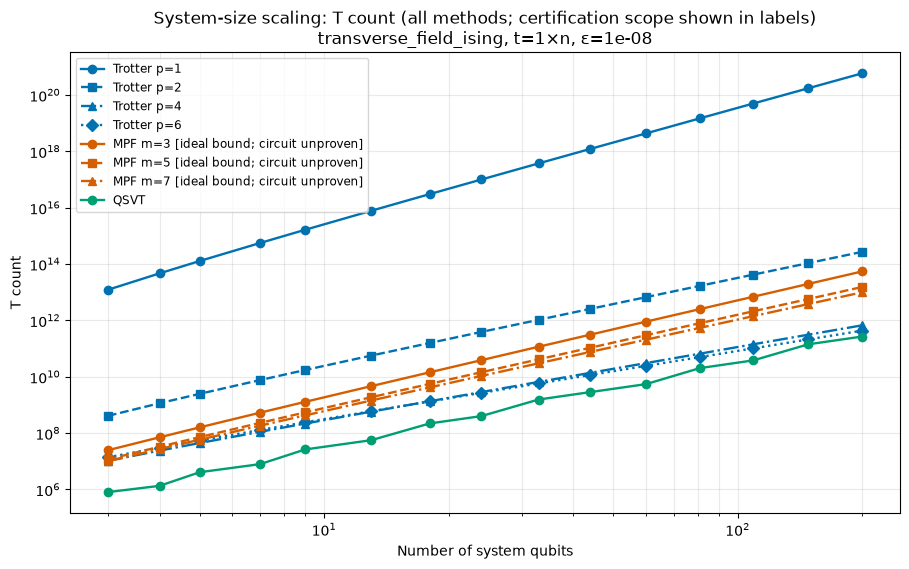

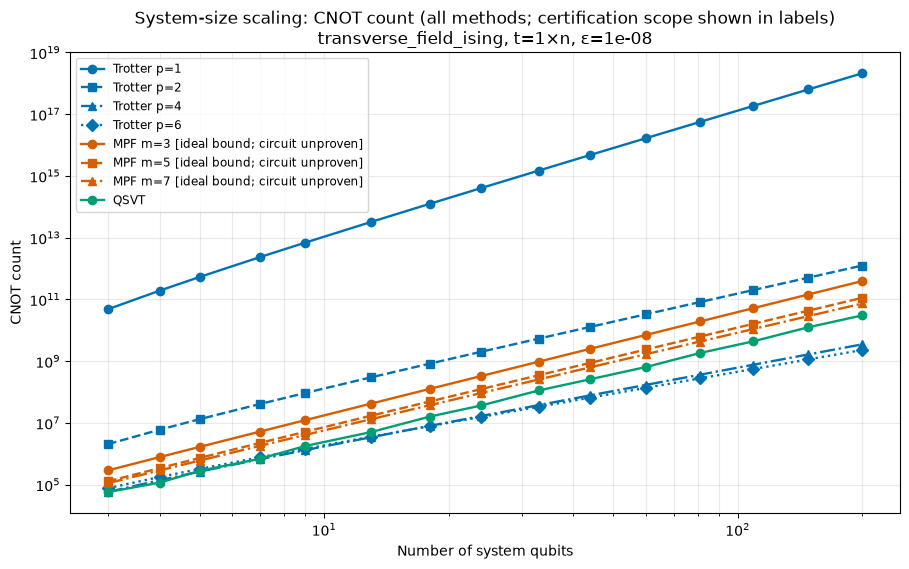

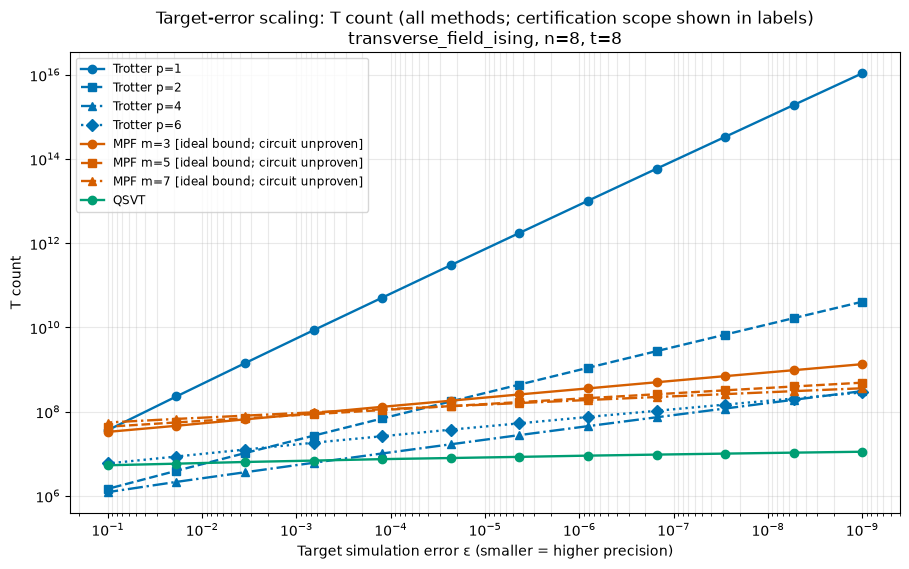

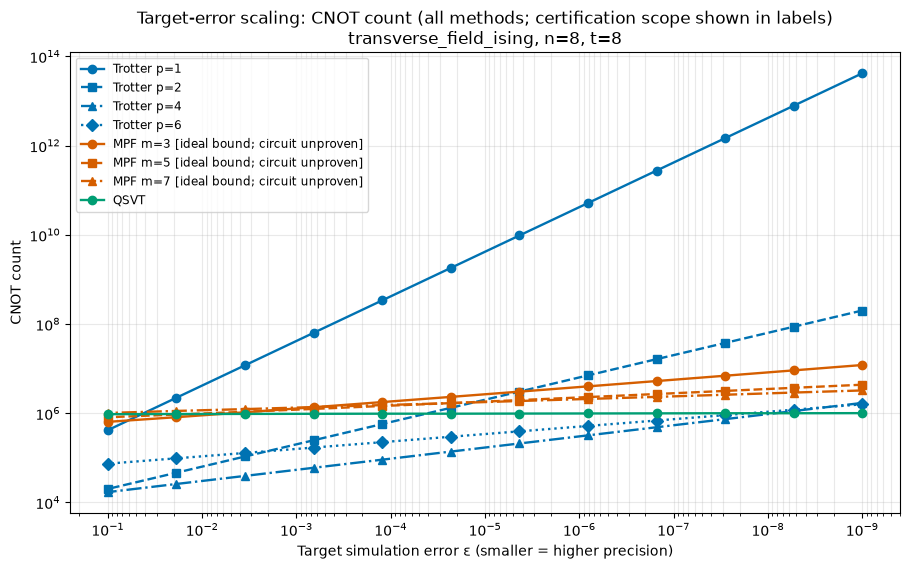

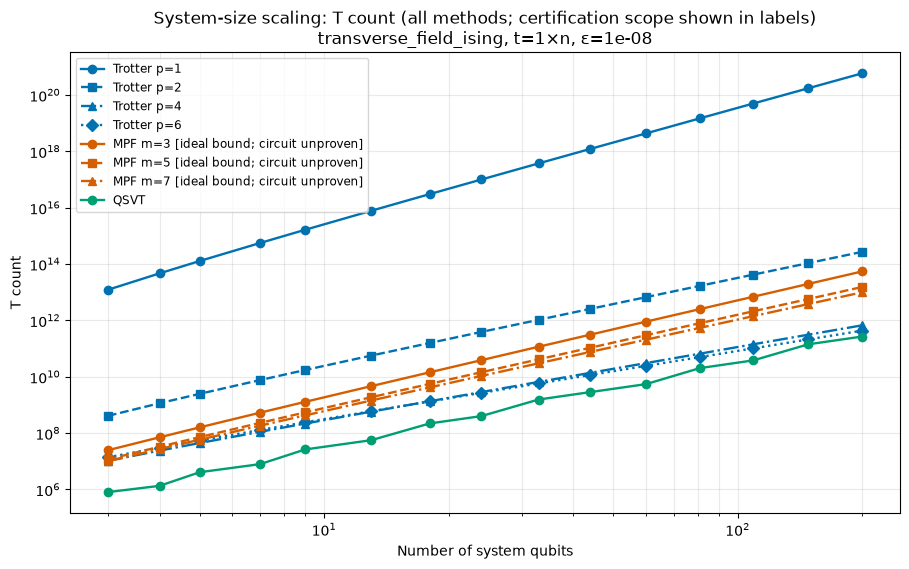

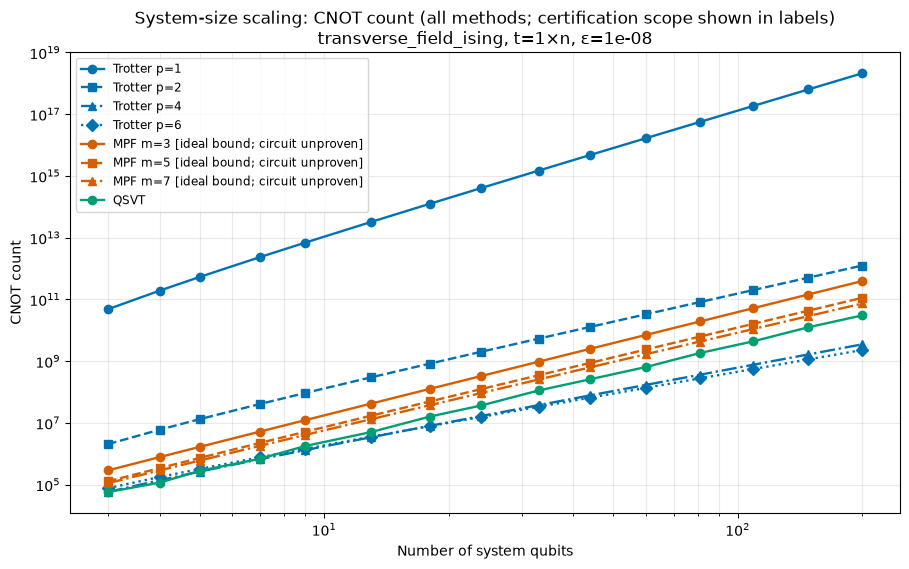

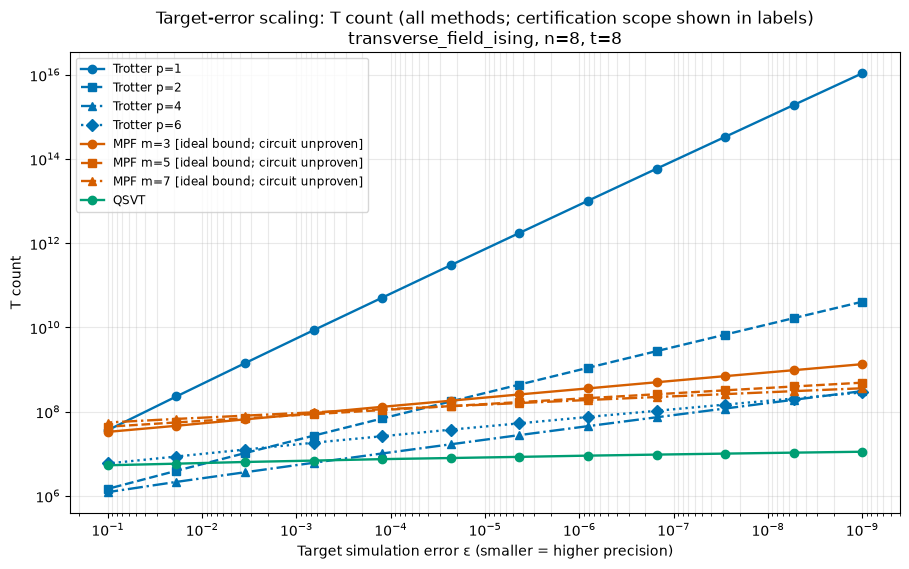

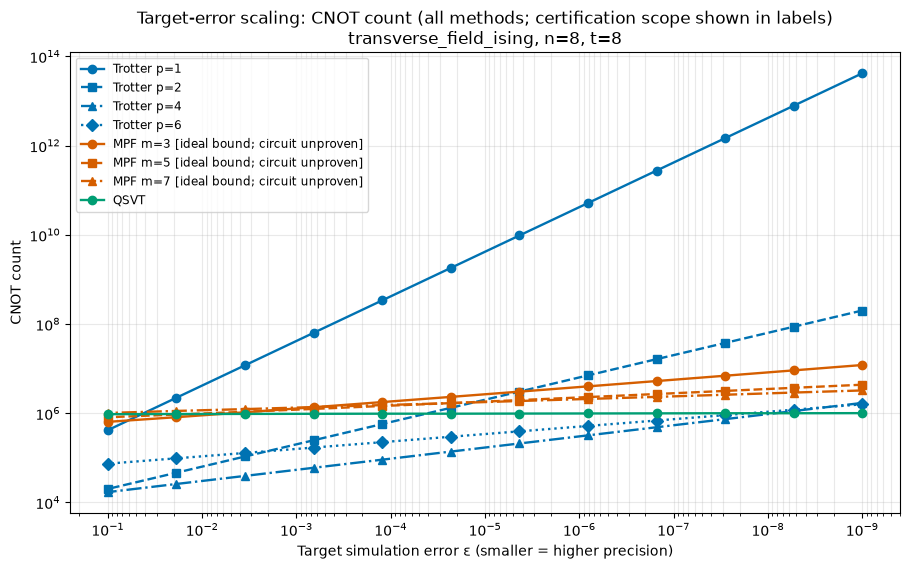

In [6]:
figures = (
    plot_benchmark(benchmark_data, sweep="system-size", metric="t_count"),
    plot_benchmark(benchmark_data, sweep="system-size", metric="cnot_count"),
    plot_benchmark(benchmark_data, sweep="target-error", metric="t_count"),
    plot_benchmark(benchmark_data, sweep="target-error", metric="cnot_count"),
)
for figure in figures:
    display(figure)

## 4. 必要な場合だけ保存

Python APIは既定では何も保存しません。結果を残す場合だけ次のセルのコメントを外してください。実行ごとに新しいrun directoryが作られ、以前の結果は上書きされません。

In [7]:
# run_directory, csv_path, metadata_path = save_benchmark(
#     benchmark_data, benchmark_config, output_root="../benchmark_outputs"
# )
# run_directory

### 解釈上の注意

- QSVT の PREPARE/SELECT コストは Hamiltonian の入力モデルに強く依存します。ここでは一般の Pauli-LCU を公平に数えています。
- 8構成とも同じbackend非依存planから得た解析回路コストの比較です。planは論理演算だけを保持し、temporary-AND、分解後のrotation/CNOT、work qubitは構造化解析backendがprovenance付きで計算します。MPF と QSVT の解析値は segment / 回路ごとの 3-step robust OAA を含みます。MPFの完全回路成功確率は未証明なので`nominal_success_probability`を空欄にしています。
- Trotter次数1, 2はChilds交換子上界、次数4, 6はgroup数がwork cap内ならSchubert--Mendl交換子上界を使います。fallbackはCSVの`bound_method`と`bound_rigorous`で明示されます。QSVTの次数は厳密なJacobi–Anger打ち切りです。MPFは既定でLow–Kliuchnikov–Wiebe Eq. (14)--(16)の`low2019-l1-ideal-rigorous` selectorを使いますが、厳密性scopeはideal MPF operatorです。robust-OAA共有ancilla回路は`circuit_bound_rigorous=False`です。
- 解析モデルの controlled QSVT は、`V`/`V^dagger` が block-encoding query を共有し projector 位相のみ選択する効率的コンパイルを仮定します。
- $t(n)=n$ は伝播速度を厳密に推定したものではなく、局所相互作用が系全体へ広がる時間をサイズに比例させる比較規約です。
- family summaryは各x値でrigorousかつ宣言scope内でtargetを満たすrowだけをpost-processし、`selected_method_id`に選択された次数・項数を残します。`legacy-w2-proxy` rowはfull plotではheuristic表示され、summaryから除外されます。